In [1]:
# load a matrix from a space-separated file and show it as an image
import sys
sys.path.append('/homes/ar2342/one_more_dir/contextual_frogs/experimental/optim/')
sys.path.append('/homes/ar2342/one_more_dir/contextual_frogs/')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import os
from stat_utils import bic_gaussian_from_rmse
result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_part2_try2/'

In [2]:


a_exp = np.loadtxt(os.path.join(result_path, 'a_exp.txt'))
a_pred = np.loadtxt(os.path.join(result_path, 'a_pred.txt'))


seeds = 5
subjs = a_exp.shape[1] // seeds

In [12]:
rmse = np.sqrt(np.nanmean((a_exp - a_pred) ** 2,axis=0)).reshape([subjs, seeds])
n_samples = np.sum(~np.isnan(a_exp),axis=0).reshape([subjs, seeds])
#ensure n_samples is same in every row
assert np.all(n_samples == n_samples[:, [0]])
n_samples = n_samples[:, 0]

best_seed_idx = np.argmin(rmse, axis=1)
best_rmse = np.min(rmse, axis=1)

In [13]:
n_samples

array([165, 165, 165, 165, 165, 165, 165, 165, 167, 167, 167, 167, 167,
       167, 167, 167])

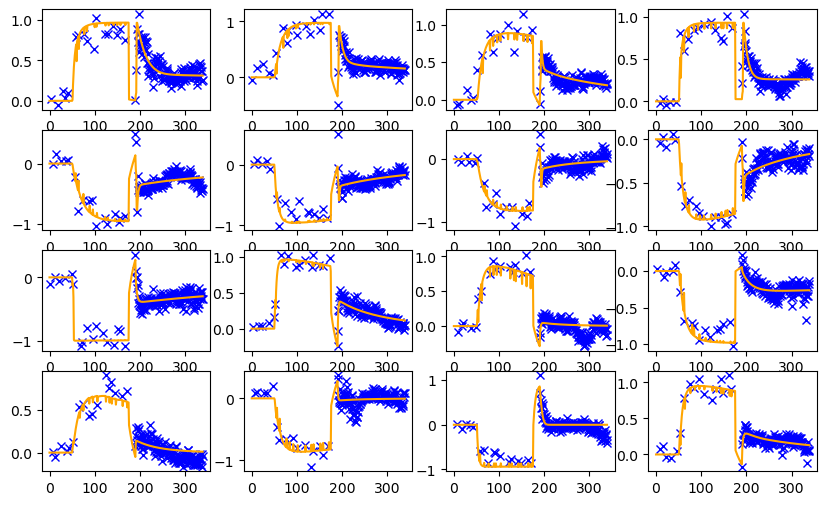

In [14]:

plt.figure(figsize=(10, 6))
plt.subplot(4, 4, 1)
for ii, (this_exp, this_pred) in enumerate(zip(a_exp.T, a_pred.T)):
    plt.subplot(4, 4, 1 + ii//seeds)
    if ii % seeds == 0:
        plt.plot(this_exp,'x', label='Experimental', color='blue')
    if ii % seeds == best_seed_idx[ii//seeds]:
        plt.plot(this_pred, label='Predicted', color='orange')
    # plt.xlabel('trials')
    # plt.ylabel('adaptation')
    # plt.title('Experimental vs Predicted Data')

In [15]:
# rmse = np.sqrt(np.nanmean((a_exp - a_pred) ** 2,axis=0)).reshape([subjs, seeds])
# n_samples = np.sum(~np.isnan(a_exp),axis=0).reshape([subjs, seeds])
# best_seed_idx = np.argmin(rmse, axis=1)
# best_rmse = rmse[np.arange(subjs), best_seed_idx]

In [16]:
these_bics = [bic_gaussian_from_rmse(this_rmse, n=this_n, k=4) for this_rmse, this_n in zip(best_rmse, n_samples)]

In [17]:
coin_bics_path = '/homes/ar2342/one_more_dir/contextual_frogs/experimental/optim/coin_bics1000.txt'
coin_bics = np.loadtxt(coin_bics_path)

In [18]:
n_samples

array([165, 165, 165, 165, 165, 165, 165, 165, 167, 167, 167, 167, 167,
       167, 167, 167])

<StemContainer object of 3 artists>

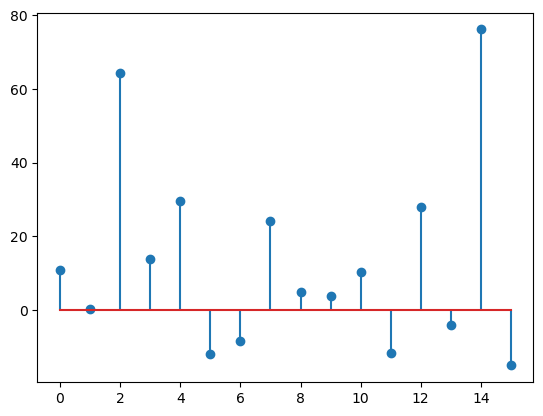

In [19]:
plt.stem(these_bics-coin_bics)

In [20]:
best_rmse

array([0.09675333, 0.09027425, 0.09328223, 0.08912233, 0.11363737,
       0.09924   , 0.09550198, 0.08693679, 0.08806151, 0.06833232,
       0.10263043, 0.09165169, 0.09372085, 0.10917024, 0.12765771,
       0.06600479])